In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")

In [2]:
# =========================================================
# 2. DATA LOADING
# =========================================================
df = pd.read_csv('/content/student_performance_dataset.csv')
df.head()


,student_id,age,study_hours_per_day,attendance_percent,assignments_score,previous_marks,internet_access,part_time_job,extra_classes,final_exam_score,pass_fail
0,S1001,24,2.8,63,72,98,Yes,No,No,71,Pass
1,S1002,21,1.5,81,45,97,Yes,Yes,No,54,Pass
2,S1003,22,3.6,95,86,67,Yes,No,No,77,Pass
3,S1004,24,6.2,92,54,75,Yes,Yes,Yes,72,Pass
4,S1005,20,4.9,65,71,82,Yes,No,Yes,81,Pass


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           500 non-null    object 
 1   age                  500 non-null    int64  
 2   study_hours_per_day  500 non-null    float64
 3   attendance_percent   500 non-null    int64  
 4   assignments_score    500 non-null    int64  
 5   previous_marks       500 non-null    int64  
 6   internet_access      500 non-null    object 
 7   part_time_job        500 non-null    object 
 8   extra_classes        500 non-null    object 
 9   final_exam_score     500 non-null    int64  
 10  pass_fail            500 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 43.1+ KB
student_id             0
age                    0
study_hours_per_day    0
attendance_percent     0
assignments_score      0
previous_marks         0
internet_access        0
part_ti

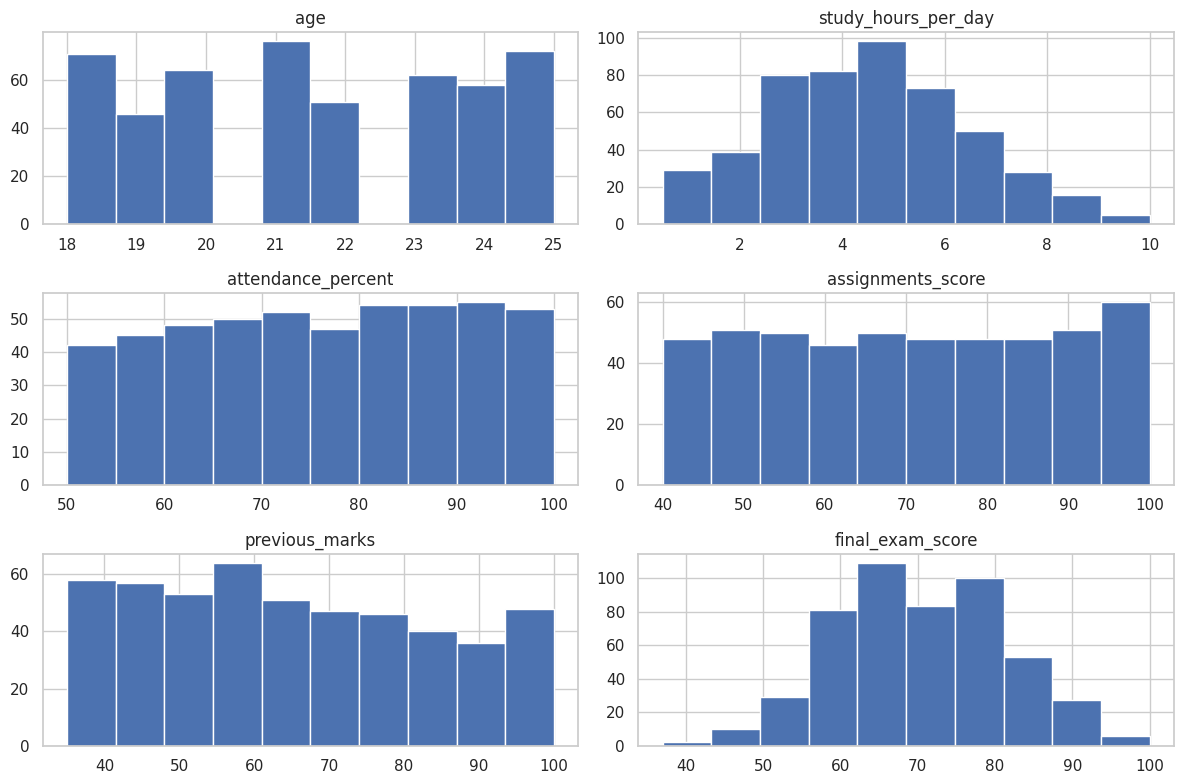

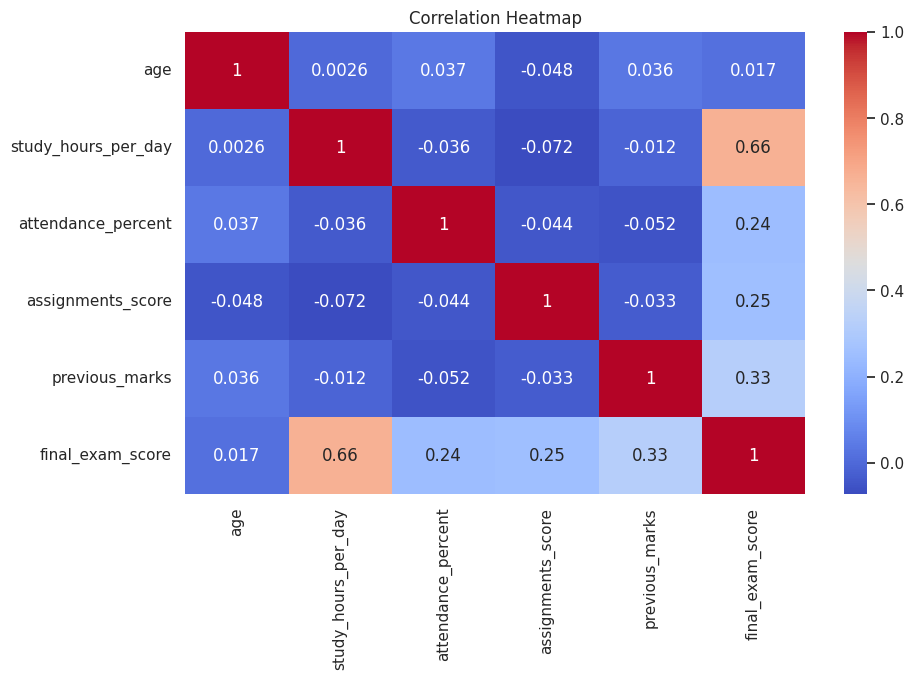

In [3]:
# =========================================================
# 3. DATA EXPLORATION (EDA)
# =========================================================

df.info()

df.describe()

missing_values = df.isnull().sum()
print(missing_values)

df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [4]:
# =========================================================
# 4. DATA PREPROCESSING
# =========================================================

data = df.copy()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].mean(), inplace=True)

label_encoders = {}
for col in data.columns:
    if data[col].dtype == 'object':
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le

data.head()

/tmp/ipykernel_19097/2123978977.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
/tmp/ipykernel_19097/2123978977.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

,student_id,age,study_hours_per_day,attendance_percent,assignments_score,previous_marks,internet_access,part_time_job,extra_classes,final_exam_score,pass_fail
0,0,24,2.8,63,72,98,1,0,0,71,1
1,1,21,1.5,81,45,97,1,1,0,54,1
2,2,22,3.6,95,86,67,1,0,0,77,1
3,3,24,6.2,92,54,75,1,1,1,72,1
4,4,20,4.9,65,71,82,1,0,1,81,1


In [5]:
# =========================================================
# 5. TRAIN-TEST SPLIT
# =========================================================

target_column = data.columns[-1]

X = data.drop(target_column, axis=1)
y = data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(400, 10) (100, 10)


In [6]:
# =========================================================
# 6. MODEL IMPLEMENTATION
# =========================================================

# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
# =========================================================
# 7. MODEL EVALUATION FUNCTION
# =========================================================

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n--- {model_name} ---")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, prec, rec, f1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


--- Logistic Regression ---
Accuracy: 0.97
Precision: 0.9409000000000001
Recall: 0.97
F1 Score: 0.9552284263959391

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.97      1.00      0.98        97

    accuracy                           0.97       100
   macro avg       0.48      0.50      0.49       100
weighted avg       0.94      0.97      0.96       100



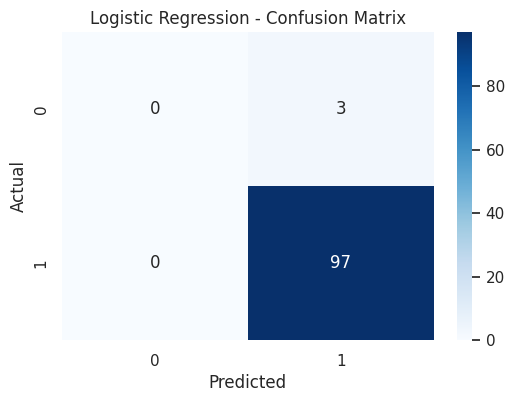


--- Random Forest ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        97

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



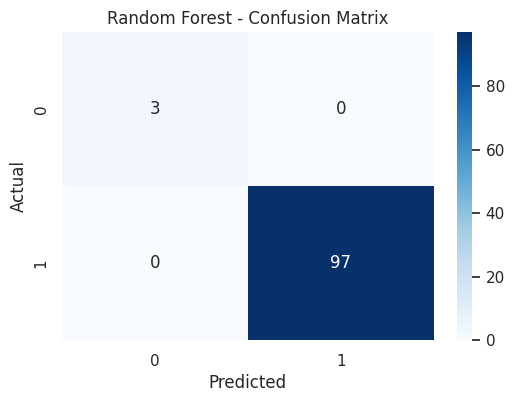

In [8]:
# =========================================================
# 8. EVALUATE MODELS
# =========================================================

lr_metrics = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

rf_metrics = evaluate_model(rf_model, X_test, y_test, "Random Forest")


                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression      0.97     0.9409    0.97  0.955228
1        Random Forest      1.00     1.0000    1.00  1.000000


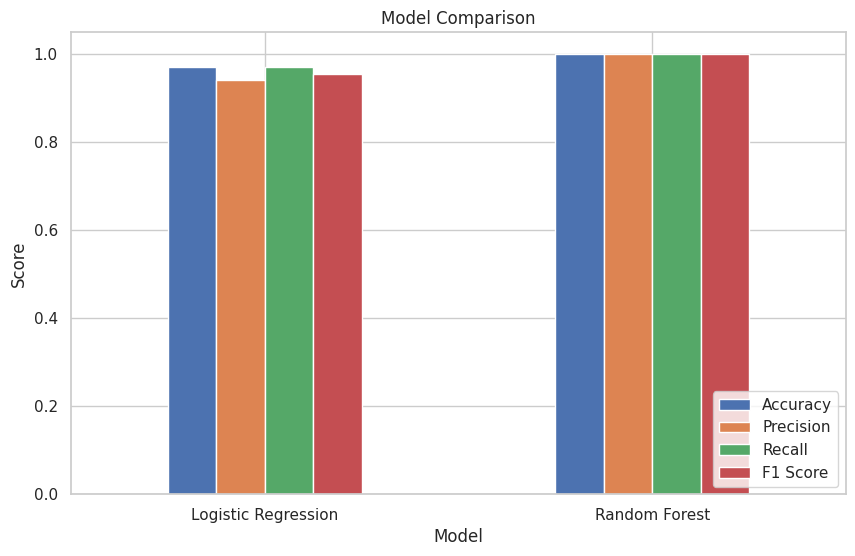

In [9]:
# =========================================================
# 9. MODEL COMPARISON
# =========================================================

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_metrics[0], rf_metrics[0]],
    "Precision": [lr_metrics[1], rf_metrics[1]],
    "Recall": [lr_metrics[2], rf_metrics[2]],
    "F1 Score": [lr_metrics[3], rf_metrics[3]]
})

print(comparison_df)

comparison_df.set_index("Model").plot(kind='bar', figsize=(10, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


In [10]:
# =========================================================
# 10. FINAL MODEL SELECTION
# =========================================================

best_model = comparison_df.sort_values(by="F1 Score", ascending=False).iloc[0]

print("Best Model Selected:")
print(best_model)


Best Model Selected:
Model        Random Forest
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1 Score               1.0
Name: 1, dtype: object


In [11]:
# =========================================================
# 11. SAVE MODELS AND PREPROCESSING AS .PKL FILES
# =========================================================

import pickle
import os

# create folder
os.makedirs("saved_models", exist_ok=True)

# save Logistic Regression model
with open("saved_models/logistic_regression_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# save Random Forest model
with open("saved_models/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# save scaler
with open("saved_models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# save label encoders
with open("saved_models/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

# save useful metadata
metadata = {
    "target_column": target_column,
    "feature_columns": X.columns.tolist()
}

with open("saved_models/metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

print("All PKL files saved successfully in 'saved_models/' folder")
print(os.listdir("saved_models"))

All PKL files saved successfully in 'saved_models/' folder
['label_encoders.pkl', 'random_forest_model.pkl', 'scaler.pkl', 'metadata.pkl', 'logistic_regression_model.pkl']
